In [2]:
import pandas as pd

# 假设数据文件名为 processed_data.csv
df = pd.read_csv('/Users/ronnygottheway/Desktop/美赛/data/cleaned_data/final_outputs.csv')

In [3]:
def rank_method(group):
    # 评委分数排名（假设使用 mean_score）
    group['judge_rank'] = group['mean_score'].rank(ascending=False, method='min')
    # 粉丝票数排名
    group['fan_rank'] = group['popularity_oof'].rank(ascending=False, method='min')
    # 综合排名
    group['combined_rank'] = group['judge_rank'] + group['fan_rank']
    # 淘汰预测：综合排名最高的选手被淘汰
    group['elim_pred_rank'] = group['combined_rank'] == group['combined_rank'].max()
    return group

df_rank = df.groupby(['season', 'week']).apply(rank_method).reset_index(drop=True)

/var/folders/6d/r8v3wkt15595tj6hq0kwh7rc0000gn/T/ipykernel_4992/3409886947.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_rank = df.groupby(['season', 'week']).apply(rank_method).reset_index(drop=True)


In [4]:
def percent_method(group):
    # 评委分数百分比
    group['judge_percent'] = group['mean_score'] / group['mean_score'].sum()
    # 粉丝票数百分比
    group['fan_percent'] = group['popularity_oof'] / group['popularity_oof'].sum()
    # 综合百分比
    group['combined_percent'] = group['judge_percent'] + group['fan_percent']
    # 淘汰预测：综合百分比最低的选手被淘汰
    group['elim_pred_percent'] = group['combined_percent'] == group['combined_percent'].min()
    return group

df_percent = df.groupby(['season', 'week']).apply(percent_method).reset_index(drop=True)

/var/folders/6d/r8v3wkt15595tj6hq0kwh7rc0000gn/T/ipykernel_4992/3967693747.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_percent = df.groupby(['season', 'week']).apply(percent_method).reset_index(drop=True)


In [5]:
# 合并两种方法的预测结果
comparison = df_rank[['season', 'week', 'celebrity_name', 'elim_pred_rank', 'if_elim']].copy()
comparison['elim_pred_percent'] = df_percent['elim_pred_percent']

# 计算两种方法预测的一致性
comparison['same_pred'] = comparison['elim_pred_rank'] == comparison['elim_pred_percent']

# 统计一致性和不一致的周数
consistency_summary = comparison.groupby(['season', 'week'])['same_pred'].all().reset_index()
print(f"完全一致的周数: {consistency_summary['same_pred'].sum()}")
print(f"总周数: {len(consistency_summary)}")
print(f"一致率: {consistency_summary['same_pred'].sum() / len(consistency_summary):.2%}")

完全一致的周数: 221
总周数: 335
一致率: 65.97%


In [6]:
# 计算粉丝票数在两种方法中的“权重”
# 排名法中：粉丝排名与综合排名的相关性
corr_rank = df_rank[['fan_rank', 'combined_rank']].corr().iloc[0,1]

# 百分比法中：粉丝百分比与综合百分比的相关性
corr_percent = df_percent[['fan_percent', 'combined_percent']].corr().iloc[0,1]

print(f"排名法中粉丝与综合排名相关性: {corr_rank:.3f}")
print(f"百分比法中粉丝与综合百分比相关性: {corr_percent:.3f}")

if corr_rank > corr_percent:
    print("排名法更偏向粉丝票数")
elif corr_percent > corr_rank:
    print("百分比法更偏向粉丝票数")
else:
    print("两种方法对粉丝票数的偏向程度相似")

排名法中粉丝与综合排名相关性: 0.966
百分比法中粉丝与综合百分比相关性: 0.973
百分比法更偏向粉丝票数


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 假设你的数据已经加载到 df 中
# 请确保 df 包含以下列：season, week, celebrity_name, mean_score, popularity_oof, if_elim

def calculate_and_compare_methods(df):
    """
    计算并比较两种投票方法
    """
    results = []
    
    for (season, week), week_data in df.groupby(['season', 'week']):
        if len(week_data) < 2:
            continue
            
        # 复制数据避免修改原数据
        data = week_data.copy()
        
        # 方法1: 排名法 (Rank Method)
        # 评委分数排名 (越高越好，排名数字越小)
        data['judge_rank'] = data['mean_score'].rank(ascending=False, method='min')
        # 粉丝票数排名 (越高越好，排名数字越小)
        data['fan_rank'] = data['popularity_oof'].rank(ascending=False, method='min')
        # 综合排名 (越小越好)
        data['combined_rank'] = data['judge_rank'] + data['fan_rank']
        # 预测淘汰者：综合排名最高的（即最差的）
        rank_elim_pred = data['combined_rank'].idxmax()
        
        # 方法2: 百分比法 (Percentage Method)
        # 评委分数百分比
        data['judge_percent'] = data['mean_score'] / data['mean_score'].sum()
        # 粉丝票数百分比
        data['fan_percent'] = data['popularity_oof'] / data['popularity_oof'].sum()
        # 综合百分比
        data['combined_percent'] = data['judge_percent'] + data['fan_percent']
        # 预测淘汰者：综合百分比最低的
        percent_elim_pred = data['combined_percent'].idxmin()
        
        # 实际淘汰者
        actual_elim = data[data['if_elim'] == 1]
        actual_elim_name = None if actual_elim.empty else actual_elim.iloc[0]['celebrity_name']
        
        # 收集结果
        results.append({
            'season': season,
            'week': week,
            'n_contestants': len(data),
            'actual_eliminated': actual_elim_name,
            'rank_predicted': data.loc[rank_elim_pred, 'celebrity_name'],
            'percent_predicted': data.loc[percent_elim_pred, 'celebrity_name'],
            'rank_correct': data.loc[rank_elim_pred, 'celebrity_name'] == actual_elim_name if actual_elim_name else False,
            'percent_correct': data.loc[percent_elim_pred, 'celebrity_name'] == actual_elim_name if actual_elim_name else False,
            'methods_agree': data.loc[rank_elim_pred, 'celebrity_name'] == data.loc[percent_elim_pred, 'celebrity_name']
        })
    
    return pd.DataFrame(results)

# 运行分析
comparison_df = calculate_and_compare_methods(df)
print("Comparison results:")
print(comparison_df.head(20))

# 分析总体表现
print("\n=== OVERALL PERFORMANCE ===")
print(f"Total weeks analyzed: {len(comparison_df)}")
print(f"Weeks with actual elimination: {comparison_df['actual_eliminated'].notna().sum()}")
print(f"Rank method accuracy: {comparison_df['rank_correct'].mean():.2%}")
print(f"Percentage method accuracy: {comparison_df['percent_correct'].mean():.2%}")
print(f"Methods agree rate: {comparison_df['methods_agree'].mean():.2%}")

Comparison results:
    season  week  n_contestants  actual_eliminated     rank_predicted  \
0        1     1              6               None  Evander Holyfield   
1        1     2              6      Trista Sutter  Evander Holyfield   
2        1     3              5  Evander Holyfield  Evander Holyfield   
3        1     4              4      Rachel Hunter      Rachel Hunter   
4        1     5              3      Joey McIntyre      Joey McIntyre   
5        1     6              2               None      John O'Hurley   
6        2     1             10        Kenny Mayne  Giselle Fernandez   
7        2     2              9       Tatum O'Neal  Giselle Fernandez   
8        2     3              8  Giselle Fernandez  Giselle Fernandez   
9        2     4              7           Master P        Tia Carrere   
10       2     5              6        Tia Carrere        Tia Carrere   
11       2     6              5    George Hamilton    George Hamilton   
12       2     7              4

In [10]:
# 分析哪种方法更偏向粉丝
def analyze_fan_bias(df, comparison_df):
    """
    分析哪种方法更偏向粉丝票数
    """
    bias_analysis = []
    
    for _, row in comparison_df.iterrows():
        if row['actual_eliminated']:
            # 获取该周数据
            week_data = df[(df['season'] == row['season']) & (df['week'] == row['week'])]
            
            # 分析被淘汰选手的特征
            actual = week_data[week_data['celebrity_name'] == row['actual_eliminated']].iloc[0]
            
            # 计算该选手的评委分数排名和粉丝票数排名
            judge_rank_in_week = week_data['mean_score'].rank(ascending=False, method='min')
            fan_rank_in_week = week_data['popularity_oof'].rank(ascending=False, method='min')
            
            actual_judge_rank = judge_rank_in_week[week_data['celebrity_name'] == row['actual_eliminated']].values[0]
            actual_fan_rank = fan_rank_in_week[week_data['celebrity_name'] == row['actual_eliminated']].values[0]
            
            bias_analysis.append({
                'season': row['season'],
                'week': row['week'],
                'actual_judge_rank': actual_judge_rank,
                'actual_fan_rank': actual_fan_rank,
                'rank_diff': actual_fan_rank - actual_judge_rank,  # 正数表示粉丝支持更多
                'was_eliminated': True
            })
    
    bias_df = pd.DataFrame(bias_analysis)

     # 分析淘汰选手的特征
    print("\n=== FAN BIAS ANALYSIS ===")
    print(f"Average judge rank of eliminated contestants: {bias_df['actual_judge_rank'].mean():.2f}")
    print(f"Average fan rank of eliminated contestants: {bias_df['actual_fan_rank'].mean():.2f}")
    print(f"Average rank difference (fan - judge): {bias_df['rank_diff'].mean():.2f}")
    
    # 分析预测准确性 vs 粉丝支持度
    rank_correct_cases = comparison_df[comparison_df['rank_correct']]
    percent_correct_cases = comparison_df[comparison_df['percent_correct']]
    
    print(f"\nWhen Rank method is correct:")
    print(f"  - Average fan rank of eliminated: {bias_df[bias_df.index.isin(rank_correct_cases.index)]['actual_fan_rank'].mean():.2f}")
    
    print(f"\nWhen Percentage method is correct:")
    print(f"  - Average fan rank of eliminated: {bias_df[bias_df.index.isin(percent_correct_cases.index)]['actual_fan_rank'].mean():.2f}")
    
    return bias_df

    # 运行偏见分析
bias_df = analyze_fan_bias(df, comparison_df)


=== FAN BIAS ANALYSIS ===
Average judge rank of eliminated contestants: 8.44
Average fan rank of eliminated contestants: 7.40
Average rank difference (fan - judge): -1.04

When Rank method is correct:
  - Average fan rank of eliminated: 7.34

When Percentage method is correct:
  - Average fan rank of eliminated: 7.37


/var/folders/6d/r8v3wkt15595tj6hq0kwh7rc0000gn/T/ipykernel_4992/1617241569.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[1, 0].boxplot(box_data, labels=box_labels, patch_artist=True)


<Figure size 1200x800 with 0 Axes>

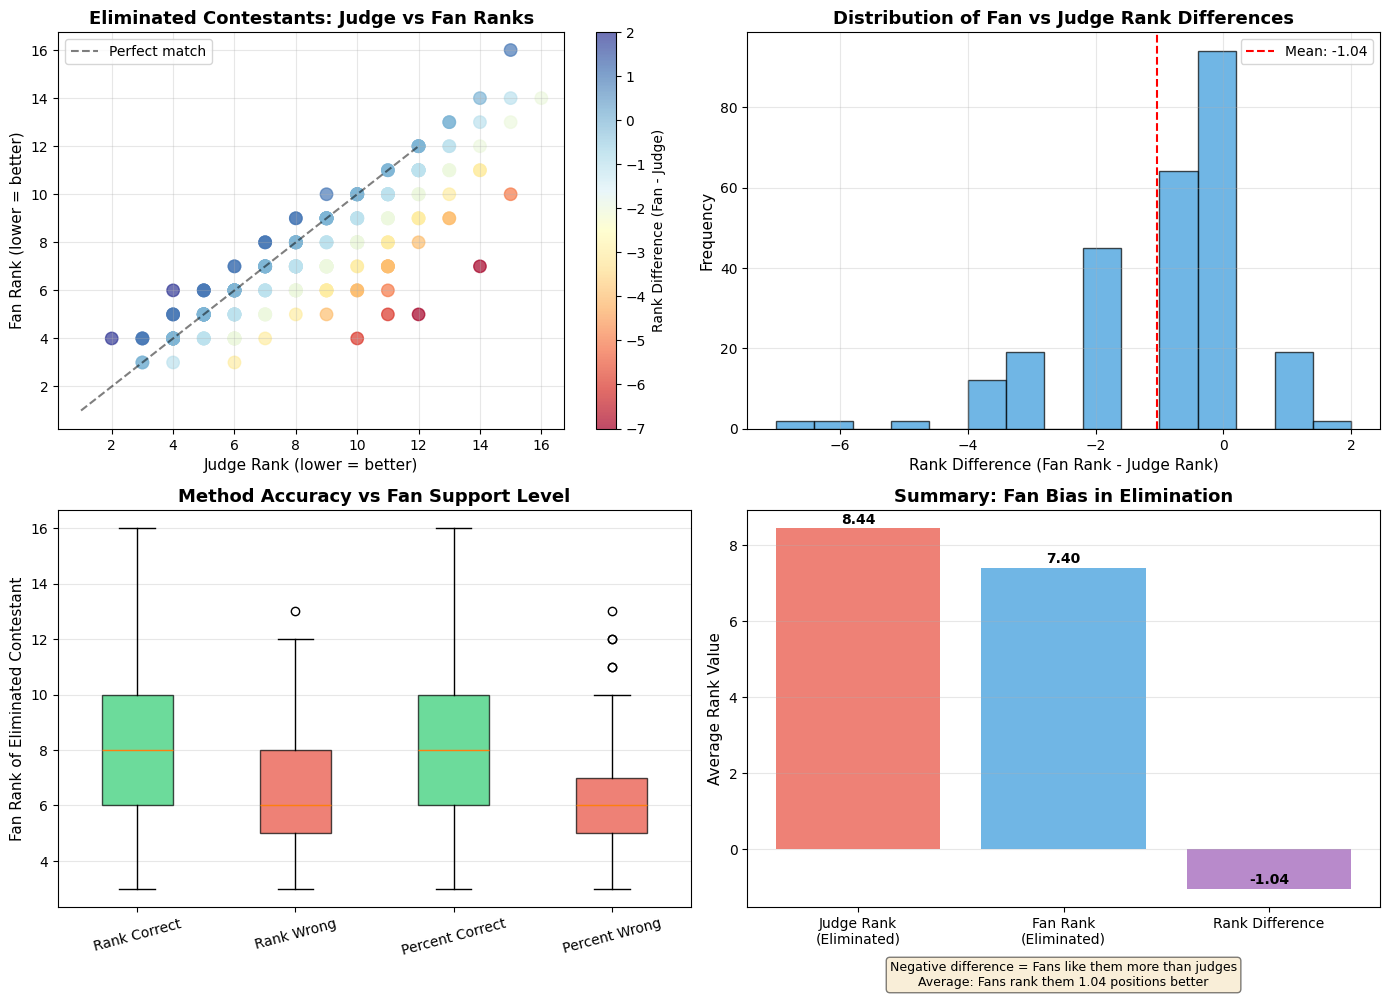


=== STATISTICAL ANALYSIS ===
1. Are fans significantly more favorable than judges?
   Paired t-test: t = 11.366, p = 0.0000
   ✓ YES: Fans are significantly more favorable (p < 0.05)

2. Which method is more accurate for different fan support levels?
   Accuracy by fan support level:
   Low Fan Support:
     Rank method accuracy: 52.34%
     Percent method accuracy: 47.66%
   Medium:
     Rank method accuracy: 55.07%
     Percent method accuracy: 49.28%
   High Fan Support:
     Rank method accuracy: 50.59%
     Percent method accuracy: 48.24%


In [14]:
from scipy import stats

# 创建粉丝偏见可视化
plt.figure(figsize=(12, 8))

# 创建子图
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 图表1: 被淘汰选手的评委vs粉丝排名分布
scatter = axes[0, 0].scatter(bias_df['actual_judge_rank'], 
                           bias_df['actual_fan_rank'],
                           c=bias_df['rank_diff'], 
                           cmap='RdYlBu', 
                           alpha=0.7,
                           s=80)
axes[0, 0].plot([1, 12], [1, 12], 'k--', alpha=0.5, label='Perfect match')
axes[0, 0].set_xlabel('Judge Rank (lower = better)', fontsize=11)
axes[0, 0].set_ylabel('Fan Rank (lower = better)', fontsize=11)
axes[0, 0].set_title('Eliminated Contestants: Judge vs Fan Ranks', fontsize=13, fontweight='bold')
plt.colorbar(scatter, ax=axes[0, 0], label='Rank Difference (Fan - Judge)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 图表2: 排名差异分布
axes[0, 1].hist(bias_df['rank_diff'], bins=15, alpha=0.7, color='#3498db', edgecolor='black')
axes[0, 1].axvline(x=bias_df['rank_diff'].mean(), color='red', linestyle='--', 
                  label=f'Mean: {bias_df["rank_diff"].mean():.2f}')
axes[0, 1].set_xlabel('Rank Difference (Fan Rank - Judge Rank)', fontsize=11)
axes[0, 1].set_ylabel('Frequency', fontsize=11)
axes[0, 1].set_title('Distribution of Fan vs Judge Rank Differences', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 图表3: 方法准确率与粉丝排名的关系
# 分组分析
methods_data = []
for idx, row in comparison_df.iterrows():
    if pd.notna(row['actual_eliminated']):
        # 找到对应的偏见数据
        bias_row = bias_df[(bias_df['season'] == row['season']) & 
                          (bias_df['week'] == row['week'])]
        if not bias_row.empty:
            methods_data.append({
                'rank_correct': row['rank_correct'],
                'percent_correct': row['percent_correct'],
                'fan_rank': bias_row.iloc[0]['actual_fan_rank'],
                'judge_rank': bias_row.iloc[0]['actual_judge_rank']
            })

methods_df = pd.DataFrame(methods_data)

# 绘制箱线图
box_data = [
    methods_df[methods_df['rank_correct']]['fan_rank'],
    methods_df[~methods_df['rank_correct']]['fan_rank'],
    methods_df[methods_df['percent_correct']]['fan_rank'],
    methods_df[~methods_df['percent_correct']]['fan_rank']
]

box_labels = ['Rank Correct', 'Rank Wrong', 'Percent Correct', 'Percent Wrong']
box_colors = ['#2ecc71', '#e74c3c', '#2ecc71', '#e74c3c']

box = axes[1, 0].boxplot(box_data, labels=box_labels, patch_artist=True)
for patch, color in zip(box['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1, 0].set_ylabel('Fan Rank of Eliminated Contestant', fontsize=11)
axes[1, 0].set_title('Method Accuracy vs Fan Support Level', fontsize=13, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=15)
axes[1, 0].grid(True, alpha=0.3, axis='y')


# 图表4: 粉丝偏向性总结
categories = ['Judge Rank\n(Eliminated)', 'Fan Rank\n(Eliminated)', 'Rank Difference']
values = [bias_df['actual_judge_rank'].mean(), 
          bias_df['actual_fan_rank'].mean(), 
          bias_df['rank_diff'].mean()]

colors = ['#e74c3c', '#3498db', '#9b59b6']
bars = axes[1, 1].bar(categories, values, color=colors, alpha=0.7)
axes[1, 1].set_ylabel('Average Rank Value', fontsize=11)
axes[1, 1].set_title('Summary: Fan Bias in Elimination', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# 添加数值标签
for bar, val in zip(bars, values):
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height + 0.05,
                   f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

# 添加解释文本
axes[1, 1].text(0.5, -0.2, 
                'Negative difference = Fans like them more than judges\n' +
                f'Average: Fans rank them {abs(bias_df["rank_diff"].mean()):.2f} positions better',
                transform=axes[1, 1].transAxes, ha='center', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# 添加统计测试
print("\n=== STATISTICAL ANALYSIS ===")
print("1. Are fans significantly more favorable than judges?")
t_stat, p_value = stats.ttest_rel(bias_df['actual_judge_rank'], bias_df['actual_fan_rank'])
print(f"   Paired t-test: t = {t_stat:.3f}, p = {p_value:.4f}")
if p_value < 0.05:
    print("   ✓ YES: Fans are significantly more favorable (p < 0.05)")
else:
    print("   ✗ NO: No significant difference")

print("\n2. Which method is more accurate for different fan support levels?")
# 按粉丝排名分组
bias_df['fan_support_level'] = pd.qcut(bias_df['actual_fan_rank'], 3, 
                                       labels=['Low Fan Support', 'Medium', 'High Fan Support'])

print("   Accuracy by fan support level:")
for level in ['Low Fan Support', 'Medium', 'High Fan Support']:
    level_cases = bias_df[bias_df['fan_support_level'] == level].index
    rank_acc = comparison_df.loc[level_cases, 'rank_correct'].mean() if len(level_cases) > 0 else np.nan
    perc_acc = comparison_df.loc[level_cases, 'percent_correct'].mean() if len(level_cases) > 0 else np.nan
    
    print(f"   {level}:")
    print(f"     Rank method accuracy: {rank_acc:.2%}" if not pd.isna(rank_acc) else "     Not enough data")
    print(f"     Percent method accuracy: {perc_acc:.2%}" if not pd.isna(perc_acc) else "     Not enough data")